In [1]:
from pathlib import Path
import re
import numpy as np
import pandas as pd

REPO_ROOT = Path("..").resolve()
STEP_DIR  = REPO_ROOT / "data/raw/step_responses"
SWEEP_CSV = REPO_ROOT / "data/raw/static_sweep_20260506_run1.csv"

STEP_START_MS = 500
SS_WINDOW_MS  = (4000, 5000)

In [2]:
PATTERN = re.compile(r"step_up_(fwd|rev)_pwm(\d+)_run(\d+)\.csv$")
FIRMWARE_PATTERN = re.compile(r"step_up_(fwd|rev)_(\d+)_run0?(\d+)\.csv$")

trials = {}
for f in sorted(STEP_DIR.glob("step_up_*.csv")):
    m = PATTERN.search(f.name) or FIRMWARE_PATTERN.search(f.name)
    if not m:
        print(f"  SKIP (no match): {f.name}")
        continue
    direction, pwm, run = m.group(1), int(m.group(2)), int(m.group(3))
    trials[(direction, pwm, run)] = pd.read_csv(f)

print(f"Loaded {len(trials)} step-up trials")
print("Conditions:", sorted({(d, p) for (d, p, _) in trials.keys()}))

Loaded 18 step-up trials
Conditions: [('fwd', 160), ('fwd', 200), ('fwd', 240), ('rev', 160), ('rev', 200), ('rev', 240)]


In [3]:
def ss_rpm(df):
    lo, hi = SS_WINDOW_MS
    mask = (df["t_ms"] >= lo + STEP_START_MS) & (df["t_ms"] <= hi + STEP_START_MS)
    return df.loc[mask, "rpm"].mean()

records = []
for (direction, pwm, run), df in trials.items():
    records.append({"direction": direction, "pwm": pwm, "run": run, "rpm_ss": ss_rpm(df)})

ss_df = pd.DataFrame(records)

agg = (ss_df.groupby(["direction", "pwm"])["rpm_ss"]
            .agg(["mean", "std", "count"])
            .reset_index()
            .rename(columns={"mean": "rpm_step_mean", "std": "rpm_step_std"}))
print(agg.to_string(index=False))

direction  pwm  rpm_step_mean  rpm_step_std  count
      fwd  160      52.358959      3.142775      3
      fwd  200     123.885385      1.308000      3
      fwd  240     210.509000      4.706710      3
      rev  160     -69.753217      1.826446      3
      rev  200    -131.836073      0.688417      3
      rev  240    -222.733367      2.513944      3


In [4]:
sweep = pd.read_csv(SWEEP_CSV)
print("Sweep columns:", list(sweep.columns))
print(sweep.head())

Sweep columns: ['pwm_cmd', 'direction', 'vmean_v', 'rpm', 'notes']
   pwm_cmd direction  vmean_v  rpm  \
0       10       fwd   -0.220  0.0   
1       20       fwd   -0.247  0.0   
2       30       fwd   -0.240  0.0   
3       40       fwd   -0.245  0.0   
4       50       fwd   -0.355  0.0   

                                               notes  
0  Ch1=12.2; Ch2=12.4; Math=-220mV; PSU_current_A...  
1  Ch1=11.7; Ch2=11.9; Math=-247mV; PSU_current_A...  
2  Ch1=11.2; Ch2=11.3; Math=-240mV; PSU_current_A...  
3  Ch1=10.7; Ch2=10.8; Math=-245mV; PSU_current_A...  
4  Ch1=3.9-4.1V; Ch2=4.7V; Math=-355mV; PSU_curre...  


In [5]:
target_pwm = [160, 200, 240]
sweep_sub = (sweep[sweep["pwm_cmd"].isin(target_pwm)]
             [["direction", "pwm_cmd", "rpm", "vmean_v"]]
             .rename(columns={"pwm_cmd": "pwm",
                              "rpm": "rpm_sweep",
                              "vmean_v": "vmean_sweep"}))

print("Sweep values at our 3 target PWMs:")
print(sweep_sub.to_string(index=False))
print()

xval = agg.merge(sweep_sub, on=["direction", "pwm"], how="left")
xval["disagreement_pct"] = 100 * (xval["rpm_step_mean"] - xval["rpm_sweep"]) / xval["rpm_sweep"]
xval["flag"] = xval["disagreement_pct"].abs() > 5

print("Cross-validation:")
print(xval.to_string(index=False))

Sweep values at our 3 target PWMs:
direction  pwm  rpm_sweep  vmean_sweep
      fwd  160       70.0         2.20
      fwd  200      130.5         4.85
      fwd  240      223.0         8.41
      rev  160      -78.5        -3.48
      rev  200     -135.0        -5.79
      rev  240     -225.0        -8.93

Cross-validation:
direction  pwm  rpm_step_mean  rpm_step_std  count  rpm_sweep  vmean_sweep  disagreement_pct  flag
      fwd  160      52.358959      3.142775      3       70.0         2.20        -25.201488  True
      fwd  200     123.885385      1.308000      3      130.5         4.85         -5.068671  True
      fwd  240     210.509000      4.706710      3      223.0         8.41         -5.601345  True
      rev  160     -69.753217      1.826446      3      -78.5        -3.48        -11.142399  True
      rev  200    -131.836073      0.688417      3     -135.0        -5.79         -2.343649 False
      rev  240    -222.733367      2.513944      3     -225.0        -8.93     

In [6]:
linear_regime = xval[xval["pwm"] >= 200].copy()
linear_regime["flag_3pct"] = linear_regime["disagreement_pct"].abs() > 3
linear_regime["flag_5pct"] = linear_regime["disagreement_pct"].abs() > 5
linear_regime["flag_7pct"] = linear_regime["disagreement_pct"].abs() > 7

print("Cross-val on above-deadzone region (PWM ≥ 200):")
print(linear_regime.to_string(index=False))

Cross-val on above-deadzone region (PWM ≥ 200):
direction  pwm  rpm_step_mean  rpm_step_std  count  rpm_sweep  vmean_sweep  disagreement_pct  flag  flag_3pct  flag_5pct  flag_7pct
      fwd  200     123.885385      1.308000      3      130.5         4.85         -5.068671  True       True       True      False
      fwd  240     210.509000      4.706710      3      223.0         8.41         -5.601345  True       True       True      False
      rev  200    -131.836073      0.688417      3     -135.0        -5.79         -2.343649 False      False      False      False
      rev  240    -222.733367      2.513944      3     -225.0        -8.93         -1.007393 False      False      False      False


In [7]:
NOISE_THRESH_RPM = 2.0   # encoder/quantisation floor; tune later if needed

def fit_fopdt(df, step_start_ms=STEP_START_MS, ss_window=SS_WINDOW_MS):
    """
    Heuristic FOPDT fit:
      Td  = time from step instant to first |rpm| > NOISE_THRESH_RPM
      tau = time from (step + Td) to reach 63.2% of K_ss
    Returns signed K_ss; Td and tau are always positive.
    """
    t = df["t_ms"].values
    r = df["rpm"].values.astype(float)

    lo, hi = ss_window
    ss_mask = (t >= step_start_ms + lo) & (t <= step_start_ms + hi)
    if not ss_mask.any():
        return None
    K_ss = r[ss_mask].mean()
    sign = 1 if K_ss >= 0 else -1
    r_abs = sign * r
    K_abs = sign * K_ss

    post = t >= step_start_ms
    above = post & (r_abs > NOISE_THRESH_RPM)
    if not above.any():
        return None
    Td_ms = t[above][0] - step_start_ms

    target = 0.632 * K_abs
    crossed = post & (r_abs >= target)
    if not crossed.any():
        return None
    tau_ms = (t[crossed][0] - step_start_ms) - Td_ms

    return {"K_ss": K_ss, "Td_ms": Td_ms, "tau_ms": tau_ms, "sign": sign}

In [8]:
key = ("fwd", 200, 1)
df_test = trials[key]
fit_test = fit_fopdt(df_test)

print(f"Trial: {key}")
print(f"  K_ss   = {fit_test['K_ss']:.2f} rpm   (cross-val mean was 123.89 — should match)")
print(f"  Td_ms  = {fit_test['Td_ms']:.0f} ms    (handover predicted 5–20)")
print(f"  tau_ms = {fit_test['tau_ms']:.0f} ms   (handover predicted 100–300)")

Trial: ('fwd', 200, 1)
  K_ss   = 122.38 rpm   (cross-val mean was 123.89 — should match)
  Td_ms  = 10 ms    (handover predicted 5–20)
  tau_ms = 100 ms   (handover predicted 100–300)


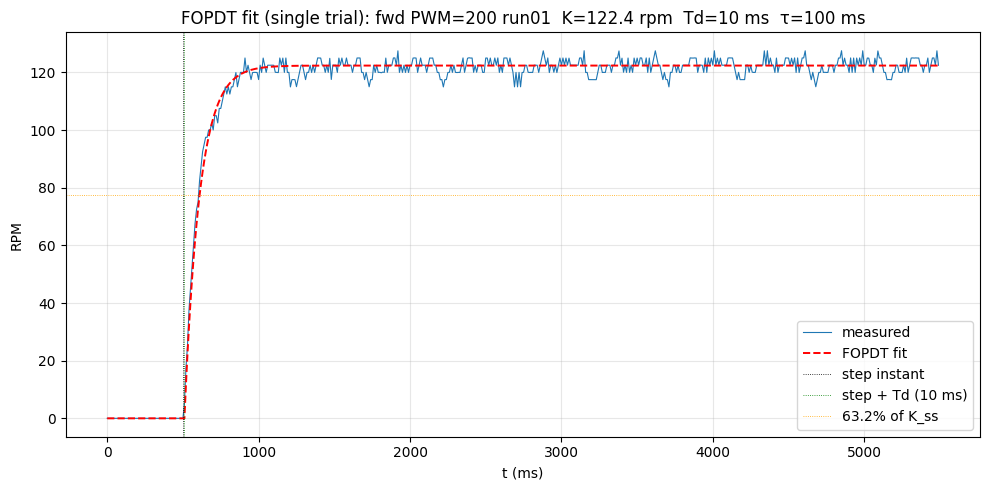

In [9]:
def fopdt_curve(t_ms, K_signed, Td, tau, step_start_ms=STEP_START_MS):
    out = np.zeros_like(t_ms, dtype=float)
    on = t_ms >= (step_start_ms + Td)
    out[on] = K_signed * (1 - np.exp(-(t_ms[on] - step_start_ms - Td) / tau))
    return out

import matplotlib.pyplot as plt

t = df_test["t_ms"].values
r = df_test["rpm"].values
curve = fopdt_curve(t, fit_test["K_ss"], fit_test["Td_ms"], fit_test["tau_ms"])

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(t, r, lw=0.8, label="measured", color="C0")
ax.plot(t, curve, "r--", lw=1.4, label="FOPDT fit")
ax.axvline(STEP_START_MS, color="k", ls=":", lw=0.6, label="step instant")
ax.axvline(STEP_START_MS + fit_test["Td_ms"], color="g", ls=":", lw=0.6,
           label=f"step + Td ({fit_test['Td_ms']:.0f} ms)")
ax.axhline(fit_test["K_ss"] * 0.632, color="orange", ls=":", lw=0.6,
           label="63.2% of K_ss")
ax.set_xlabel("t (ms)")
ax.set_ylabel("RPM")
ax.set_title(f"FOPDT fit (single trial): fwd PWM=200 run01  "
             f"K={fit_test['K_ss']:.1f} rpm  Td={fit_test['Td_ms']:.0f} ms  "
             f"τ={fit_test['tau_ms']:.0f} ms")
ax.legend(loc="lower right")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(REPO_ROOT / "figures" / "05_fopdt_fwd_200_run01.png", dpi=140)
plt.show()

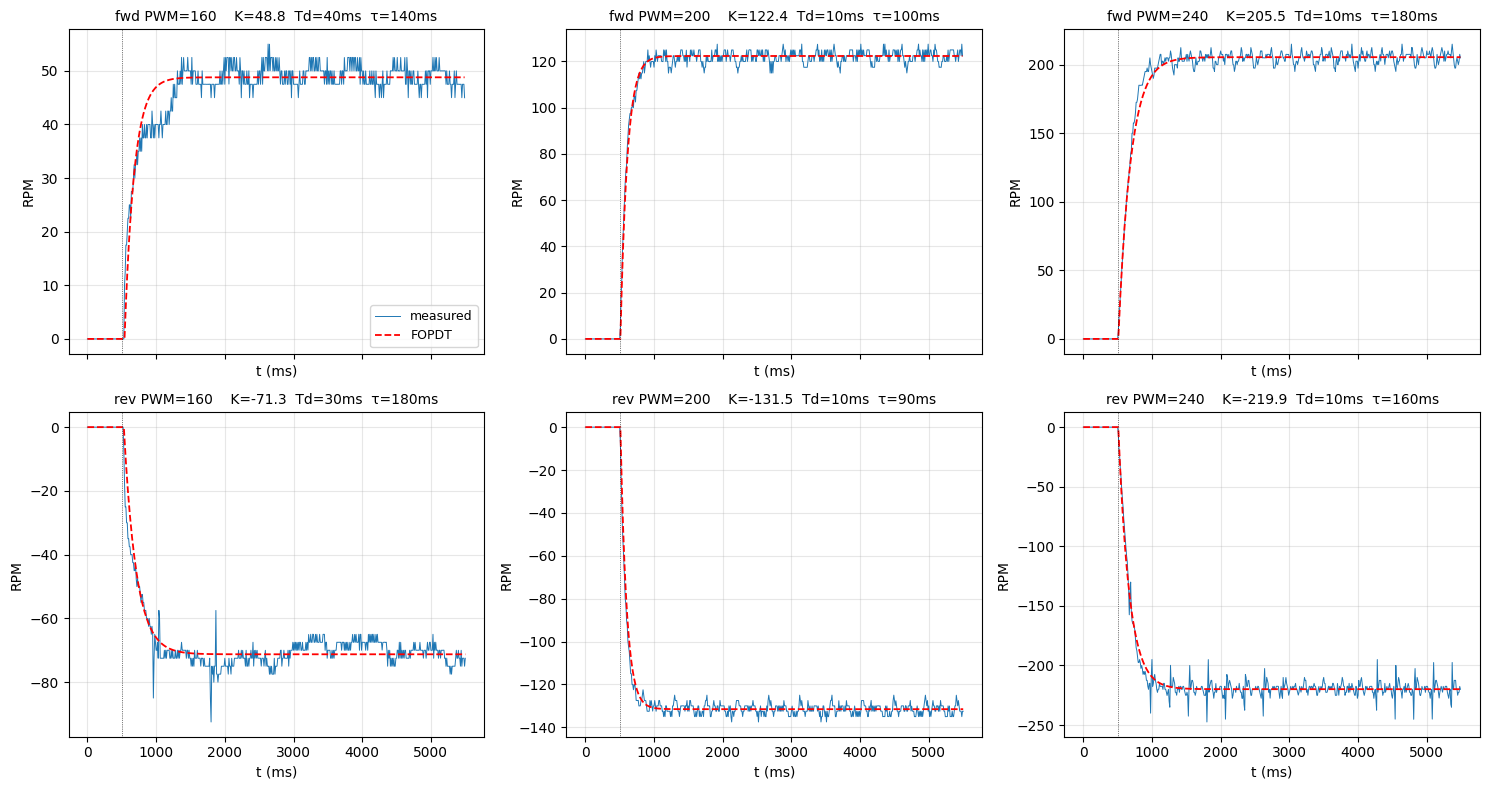


Representative fits (run01 of each condition):
condition                  K_ss    Td (ms)   tau (ms)
----------------------------------------------------
('fwd', 160, 1)            48.8         40        140
('fwd', 200, 1)           122.4         10        100
('fwd', 240, 1)           205.5         10        180
('rev', 160, 1)           -71.3         30        180
('rev', 200, 1)          -131.5         10         90
('rev', 240, 1)          -219.9         10        160


In [10]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8), sharex=True)
fits_rep = {}

for i, direction in enumerate(["fwd", "rev"]):
    for j, pwm in enumerate([160, 200, 240]):
        ax = axes[i, j]
        key = (direction, pwm, 1)
        df = trials[key]
        fit = fit_fopdt(df)
        fits_rep[key] = fit

        t = df["t_ms"].values
        r = df["rpm"].values

        ax.plot(t, r, lw=0.7, color="C0", label="measured")
        if fit is not None:
            curve = fopdt_curve(t, fit["K_ss"], fit["Td_ms"], fit["tau_ms"])
            ax.plot(t, curve, "r--", lw=1.3, label="FOPDT")
            ax.set_title(
                f"{direction} PWM={pwm}    "
                f"K={fit['K_ss']:.1f}  Td={fit['Td_ms']:.0f}ms  τ={fit['tau_ms']:.0f}ms",
                fontsize=10,
            )
        else:
            ax.set_title(f"{direction} PWM={pwm}  [fit FAILED]", fontsize=10)

        ax.axvline(STEP_START_MS, color="k", ls=":", lw=0.5)
        ax.set_xlabel("t (ms)")
        ax.set_ylabel("RPM")
        ax.grid(True, alpha=0.3)
        if i == 0 and j == 0:
            ax.legend(loc="lower right", fontsize=9)

plt.tight_layout()
plt.savefig(REPO_ROOT / "figures" / "06_fopdt_6condition_grid.png", dpi=140)
plt.show()

print("\nRepresentative fits (run01 of each condition):")
print(f"{'condition':<22} {'K_ss':>8} {'Td (ms)':>10} {'tau (ms)':>10}")
print("-" * 52)
for key in [("fwd", 160, 1), ("fwd", 200, 1), ("fwd", 240, 1),
            ("rev", 160, 1), ("rev", 200, 1), ("rev", 240, 1)]:
    f = fits_rep[key]
    if f is not None:
        print(f"{str(key):<22} {f['K_ss']:>8.1f} {f['Td_ms']:>10.0f} {f['tau_ms']:>10.0f}")
    else:
        print(f"{str(key):<22} {'FIT FAILED':>30}")

In [11]:
fit_records = []
for (direction, pwm, run), df in trials.items():
    fit = fit_fopdt(df)
    rec = {"direction": direction, "pwm": pwm, "run": run}
    if fit is None:
        rec.update({"K_ss": np.nan, "Td_ms": np.nan, "tau_ms": np.nan, "fit_ok": False})
    else:
        rec.update({"K_ss": fit["K_ss"], "Td_ms": fit["Td_ms"],
                    "tau_ms": fit["tau_ms"], "fit_ok": True})
    fit_records.append(rec)

fits_df = (pd.DataFrame(fit_records)
             .sort_values(["direction", "pwm", "run"])
             .reset_index(drop=True))

print(f"Successful fits: {fits_df['fit_ok'].sum()} / {len(fits_df)}")
print()
print(fits_df.to_string(index=False))

Successful fits: 18 / 18

direction  pwm  run        K_ss  Td_ms  tau_ms  fit_ok
      fwd  160    1   48.799900     40     140    True
      fwd  160    2   53.524600     10     180    True
      fwd  160    3   54.752376     10     180    True
      fwd  200    1  122.375600     10     100    True
      fwd  200    2  124.604554     10     100    True
      fwd  200    3  124.676000     10      90    True
      fwd  240    1  205.475400     10     180    True
      fwd  240    2  211.250900     10     170    True
      fwd  240    3  214.800700     10     170    True
      rev  160    1  -71.262277     30     180    True
      rev  160    2  -67.722772     10     190    True
      rev  160    3  -70.274600     10     140    True
      rev  200    1 -131.534158     10      90    True
      rev  200    2 -131.350200     10      90    True
      rev  200    3 -132.623861     10      90    True
      rev  240    1 -219.874800     10     160    True
      rev  240    2 -223.725200     10 

In [12]:
agg_dyn = (fits_df.groupby(["direction", "pwm"])
                  .agg(
                      K_ss_mean=("K_ss", "mean"),
                      K_ss_std =("K_ss", "std"),
                      Td_mean  =("Td_ms", "mean"),
                      Td_std   =("Td_ms", "std"),
                      tau_mean =("tau_ms", "mean"),
                      tau_std  =("tau_ms", "std"),
                      n        =("fit_ok", "sum"),
                  )
                  .reset_index())

print("Per-condition aggregates (n=3 runs each):")
print(agg_dyn.to_string(index=False))

fits_df.to_csv(REPO_ROOT / "data/processed/phase21_fopdt_per_trial.csv", index=False)
agg_dyn.to_csv(REPO_ROOT / "data/processed/phase21_fopdt_per_condition.csv", index=False)
print("\nSaved per-trial (18 rows) and per-condition (6 rows) fits to data/processed/.")

Per-condition aggregates (n=3 runs each):
direction  pwm   K_ss_mean  K_ss_std   Td_mean    Td_std   tau_mean   tau_std  n
      fwd  160   52.358959  3.142775 20.000000 17.320508 166.666667 23.094011  3
      fwd  200  123.885385  1.308000 10.000000  0.000000  96.666667  5.773503  3
      fwd  240  210.509000  4.706710 10.000000  0.000000 173.333333  5.773503  3
      rev  160  -69.753217  1.826446 16.666667 11.547005 170.000000 26.457513  3
      rev  200 -131.836073  0.688417 10.000000  0.000000  90.000000  0.000000  3
      rev  240 -222.733367  2.513944 10.000000  0.000000 170.000000 10.000000  3

Saved per-trial (18 rows) and per-condition (6 rows) fits to data/processed/.


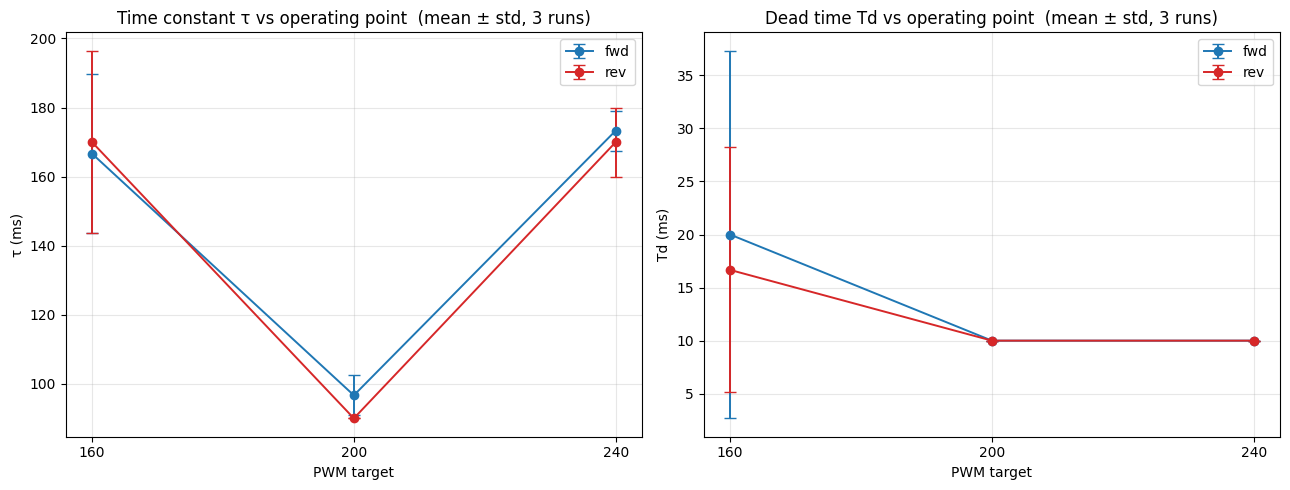

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, col_mean, col_std, ylabel, title in [
    (axes[0], "tau_mean", "tau_std", "τ (ms)",  "Time constant τ vs operating point"),
    (axes[1], "Td_mean",  "Td_std",  "Td (ms)", "Dead time Td vs operating point"),
]:
    for direction, color in [("fwd", "C0"), ("rev", "C3")]:
        sub = agg_dyn[agg_dyn["direction"] == direction]
        ax.errorbar(sub["pwm"], sub[col_mean], yerr=sub[col_std],
                    marker="o", capsize=4, lw=1.4, label=direction, color=color)
    ax.set_xlabel("PWM target")
    ax.set_ylabel(ylabel)
    ax.set_title(title + "  (mean ± std, 3 runs)")
    ax.set_xticks([160, 200, 240])
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(REPO_ROOT / "figures" / "07_tau_td_vs_pwm.png", dpi=140)
plt.show()

In [15]:
from scipy.optimize import curve_fit

def fopdt_model(t, K, Td, tau):
    """FOPDT response: 0 baseline, then exponential rise to K starting at STEP_START_MS + Td."""
    out = np.zeros_like(t, dtype=float)
    on = t >= (STEP_START_MS + Td)
    out[on] = K * (1 - np.exp(-(t[on] - STEP_START_MS - Td) / tau))
    return out

def fit_fopdt_curve(df):
    """Nonlinear FOPDT fit using heuristic as initial guess. Returns params + residual stats."""
    t = df["t_ms"].values.astype(float)
    r = df["rpm"].values.astype(float)

    h = fit_fopdt(df)
    if h is None:
        return {"fit_ok": False, "error": "heuristic failed"}

    K0, Td0, tau0 = h["K_ss"], h["Td_ms"], h["tau_ms"]
    K_max = abs(K0) * 2
    if K0 >= 0:
        lower, upper = [0, 0, 10], [K_max, 200, 1000]
    else:
        lower, upper = [-K_max, 0, 10], [0, 200, 1000]

    try:
        popt, _ = curve_fit(fopdt_model, t, r, p0=[K0, Td0, tau0],
                            bounds=(lower, upper), max_nfev=5000)
    except Exception as e:
        return {"fit_ok": False, "error": str(e)}

    K, Td, tau = popt
    res = r - fopdt_model(t, *popt)
    rise = (t >= STEP_START_MS) & (t <= STEP_START_MS + 1500)
    ss   = (t >= STEP_START_MS + 4000) & (t <= STEP_START_MS + 5000)

    return {
        "K_ss": K, "Td_ms": Td, "tau_ms": tau,
        "rms_rise":  np.sqrt(np.mean(res[rise]**2)),
        "rms_ss":    np.sqrt(np.mean(res[ss]**2)),
        "rms_total": np.sqrt(np.mean(res**2)),
        "fit_ok": True,
    }

In [16]:
records = []
for (direction, pwm, run), df in trials.items():
    f = fit_fopdt_curve(df)
    rec = {"direction": direction, "pwm": pwm, "run": run}
    if f.get("fit_ok"):
        rec.update({k: f[k] for k in ["K_ss", "Td_ms", "tau_ms",
                                        "rms_rise", "rms_ss", "rms_total"]})
        rec["fit_ok"] = True
    else:
        for k in ["K_ss", "Td_ms", "tau_ms", "rms_rise", "rms_ss", "rms_total"]:
            rec[k] = np.nan
        rec["fit_ok"] = False
    records.append(rec)

curve_df = (pd.DataFrame(records)
              .sort_values(["direction", "pwm", "run"])
              .reset_index(drop=True))

print(f"curve_fit success: {curve_df['fit_ok'].sum()} / {len(curve_df)}")
print()
print(curve_df.round(2).to_string(index=False))

curve_fit success: 18 / 18

direction  pwm  run    K_ss  Td_ms  tau_ms  rms_rise  rms_ss  rms_total  fit_ok
      fwd  160    1   48.96   0.00  225.03      3.17    1.89       2.33    True
      fwd  160    2   53.00   0.00  183.35      2.10    2.13       1.99    True
      fwd  160    3   54.28   0.00  191.90      2.58    2.34       2.24    True
      fwd  200    1  121.99   4.00   99.69      2.57    2.66       2.46    True
      fwd  200    2  124.41   5.71   95.20      2.36    2.63       2.46    True
      fwd  200    3  124.18   5.05   90.40      2.50    2.76       2.49    True
      fwd  240    1  205.09  17.76  151.83      4.54    4.25       4.00    True
      fwd  240    2  210.79  17.10  149.76      4.75    4.05       4.13    True
      fwd  240    3  213.34  16.31  155.18      4.78    4.29       4.21    True
      rev  160    1  -71.14   0.00  178.18      4.52    2.38       3.43    True
      rev  160    2  -67.87   0.00  201.78      2.88    2.47       2.54    True
      rev  1

In [17]:
curve_agg = (curve_df.groupby(["direction", "pwm"])
                     .agg(
                         K_ss_mean=("K_ss", "mean"),
                         Td_mean=("Td_ms", "mean"),  Td_std=("Td_ms", "std"),
                         tau_mean=("tau_ms", "mean"), tau_std=("tau_ms", "std"),
                         rms_rise_mean=("rms_rise", "mean"),
                         rms_ss_mean=("rms_ss", "mean"),
                     ).reset_index())

print("curve_fit per-condition aggregates:")
print(curve_agg.round(2).to_string(index=False))
print()

compare = (agg_dyn[["direction", "pwm", "tau_mean"]]
           .rename(columns={"tau_mean": "tau_heuristic"})
           .merge(curve_agg[["direction", "pwm", "tau_mean", "tau_std"]]
                    .rename(columns={"tau_mean": "tau_curvefit"}),
                  on=["direction", "pwm"]))
compare["delta_pct"] = 100 * (compare["tau_curvefit"] - compare["tau_heuristic"]) / compare["tau_heuristic"]

print("τ comparison — heuristic vs curve_fit:")
print(compare.round(2).to_string(index=False))

curve_df.to_csv(REPO_ROOT / "data/processed/phase21_fopdt_curvefit_per_trial.csv", index=False)
curve_agg.to_csv(REPO_ROOT / "data/processed/phase21_fopdt_curvefit_per_condition.csv", index=False)
print("\nSaved.")

curve_fit per-condition aggregates:
direction  pwm  K_ss_mean  Td_mean  Td_std  tau_mean  tau_std  rms_rise_mean  rms_ss_mean
      fwd  160      52.08     0.00    0.00    200.09    22.02           2.61         2.12
      fwd  200     123.53     4.92    0.86     95.10     4.64           2.48         2.68
      fwd  240     209.74    17.06    0.73    152.26     2.74           4.69         4.20
      rev  160     -69.55     0.00    0.00    191.65    12.15           4.03         2.47
      rev  200    -131.35     5.63    0.28     81.24     0.94           2.66         3.30
      rev  240    -222.56    23.49    0.64    144.43     2.45           7.17         6.00

τ comparison — heuristic vs curve_fit:
direction  pwm  tau_heuristic  tau_curvefit  tau_std  delta_pct
      fwd  160         166.67        200.09    22.02      20.06
      fwd  200          96.67         95.10     4.64      -1.62
      fwd  240         173.33        152.26     2.74     -12.16
      rev  160         170.00        1

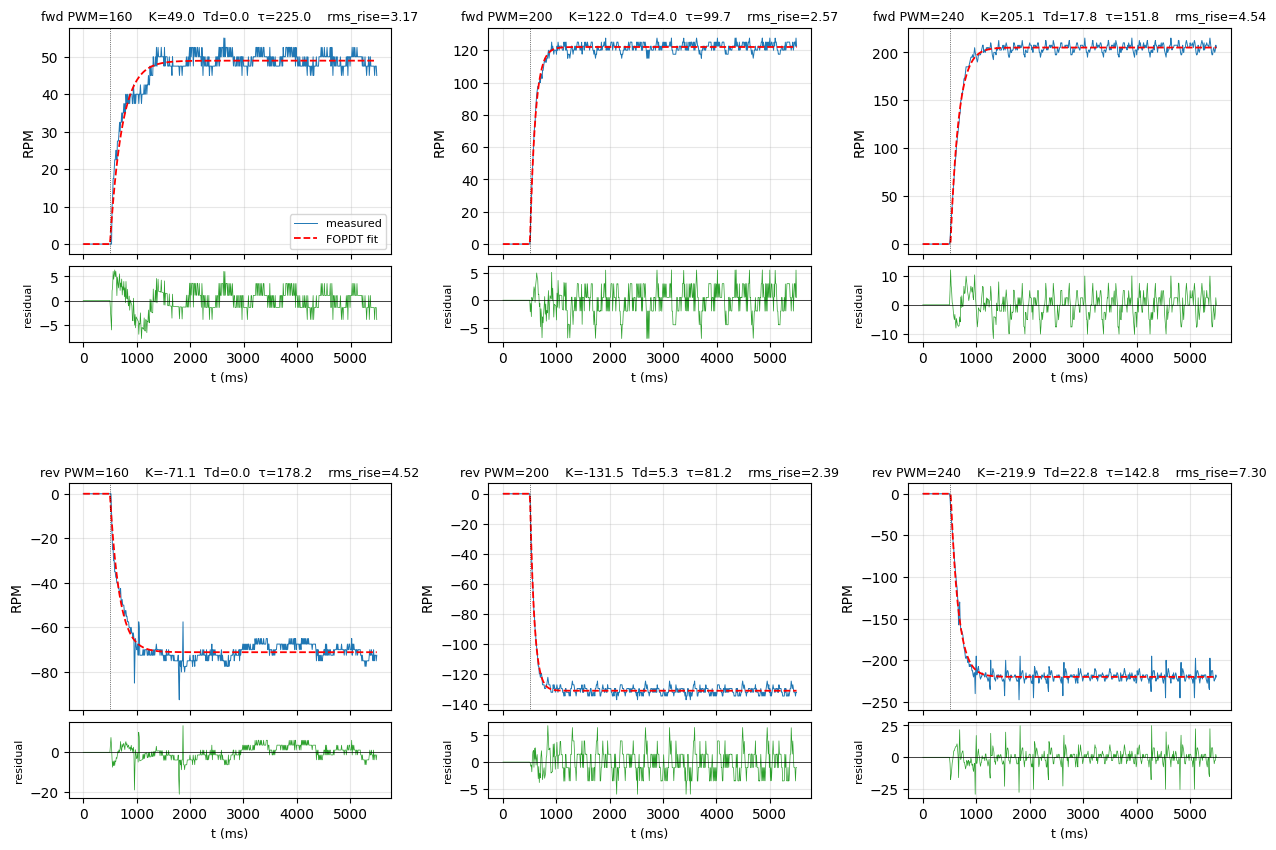

In [18]:
fig = plt.figure(figsize=(15, 10))
outer_gs = fig.add_gridspec(2, 3, hspace=0.45, wspace=0.3)

for i, direction in enumerate(["fwd", "rev"]):
    for j, pwm in enumerate([160, 200, 240]):
        inner = outer_gs[i, j].subgridspec(2, 1, height_ratios=[3, 1], hspace=0.08)
        ax_top = fig.add_subplot(inner[0])
        ax_bot = fig.add_subplot(inner[1], sharex=ax_top)

        df = trials[(direction, pwm, 1)]
        f  = fit_fopdt_curve(df)
        t  = df["t_ms"].values
        r  = df["rpm"].values

        ax_top.plot(t, r, lw=0.7, color="C0", label="measured")
        if f["fit_ok"]:
            curve = fopdt_model(t, f["K_ss"], f["Td_ms"], f["tau_ms"])
            ax_top.plot(t, curve, "r--", lw=1.3, label="FOPDT fit")
            ax_bot.plot(t, r - curve, lw=0.5, color="C2")
            ax_bot.axhline(0, color="k", lw=0.5)
            ax_top.set_title(
                f"{direction} PWM={pwm}    "
                f"K={f['K_ss']:.1f}  Td={f['Td_ms']:.1f}  τ={f['tau_ms']:.1f}    "
                f"rms_rise={f['rms_rise']:.2f}",
                fontsize=9,
            )

        ax_top.axvline(STEP_START_MS, color="k", ls=":", lw=0.5)
        ax_top.set_ylabel("RPM")
        ax_top.grid(True, alpha=0.3)
        ax_top.tick_params(labelbottom=False)
        if i == 0 and j == 0:
            ax_top.legend(loc="lower right", fontsize=8)

        ax_bot.set_ylabel("residual", fontsize=8)
        ax_bot.set_xlabel("t (ms)", fontsize=9)
        ax_bot.grid(True, alpha=0.3)

plt.savefig(REPO_ROOT / "figures" / "08_fopdt_curvefit_residuals.png", dpi=140)
plt.show()

In [21]:
# Load step-down trials.
DOWN_PATTERNS = [
    re.compile(r"step_down_(fwd|rev)_(\d+)to(\d+)_run0?(\d+)\.csv$"),
]

step_down_trials = {}
unmatched = []

for f in sorted(STEP_DIR.glob("step_down_*.csv")):
    m = None
    for p in DOWN_PATTERNS:
        m = p.search(f.name)
        if m:
            break

    if not m:
        unmatched.append(f.name)
        continue

    direction = m.group(1)
    start_pwm = int(m.group(2))
    target_pwm = int(m.group(3))
    run = int(m.group(4))

    step_down_trials[(direction, start_pwm, target_pwm, run)] = pd.read_csv(f)

print(f"Loaded {len(step_down_trials)} step-down trials")
print(f"Unmatched filenames: {unmatched}")
print("Conditions:", sorted({(d, s, tg) for (d, s, tg, _) in step_down_trials.keys()}))


Loaded 12 step-down trials
Unmatched filenames: []
Conditions: [('fwd', 240, 0), ('fwd', 240, 160), ('rev', 240, 0), ('rev', 240, 160)]


In [22]:
STEP_DOWN_START_MS  = 3000
SS_INIT_WINDOW_MS   = (2000, 3000)   # last 1 s of the start_pwm hold
SS_FINAL_WINDOW_MS  = (7000, 8000)   # last 1 s of the target_pwm hold

def fopdt_step_down_model(t, y_init, y_final, Td, tau):
    """Decay from y_init toward y_final after a step at STEP_DOWN_START_MS + Td."""
    out = np.full_like(t, y_init, dtype=float)
    on = t >= (STEP_DOWN_START_MS + Td)
    out[on] = y_final + (y_init - y_final) * np.exp(-(t[on] - STEP_DOWN_START_MS - Td) / tau)
    return out

def fit_fopdt_step_down(df):
    t = df["t_ms"].values.astype(float)
    r = df["rpm"].values.astype(float)

    init_mask  = (t >= SS_INIT_WINDOW_MS[0])  & (t <= SS_INIT_WINDOW_MS[1])
    final_mask = (t >= SS_FINAL_WINDOW_MS[0]) & (t <= SS_FINAL_WINDOW_MS[1])
    if not init_mask.any() or not final_mask.any():
        return {"fit_ok": False, "error": "ss windows empty"}

    y_init0  = r[init_mask].mean()
    y_final0 = r[final_mask].mean()
    sign = 1 if y_init0 >= 0 else -1

    if sign > 0:
        lower, upper = [0, -10, 0, 10], [400,  400, 200, 1000]
    else:
        lower, upper = [-400, -400, 0, 10], [10, 0, 200, 1000]

    try:
        popt, _ = curve_fit(
            fopdt_step_down_model, t, r,
            p0=[y_init0, y_final0, 10, 100],
            bounds=(lower, upper),
            max_nfev=5000,
        )
    except Exception as e:
        return {"fit_ok": False, "error": str(e)}

    y_init, y_final, Td, tau = popt
    res = r - fopdt_step_down_model(t, *popt)
    decel_mask = (t >= STEP_DOWN_START_MS) & (t <= STEP_DOWN_START_MS + 1500)

    return {
        "y_init": y_init, "y_final": y_final,
        "Td_ms": Td, "tau_ms": tau,
        "rms_decel": np.sqrt(np.mean(res[decel_mask]**2)),
        "rms_total": np.sqrt(np.mean(res**2)),
        "fit_ok": True,
    }

Trial: ('fwd', 240, 160, 1)
  y_init  = 215.4 rpm   (expect ≈ 210, fwd 240 SS from step-ups)
  y_final = 75.0 rpm   (expect ≈  52, fwd 160 SS from step-ups)
  Td_ms   = 18.4 ms
  tau_ms  = 265.9 ms     (compare: accel τ at PWM=200 ≈ 95, at PWM=240 ≈ 152)
  rms_decel = 4.31 rpm


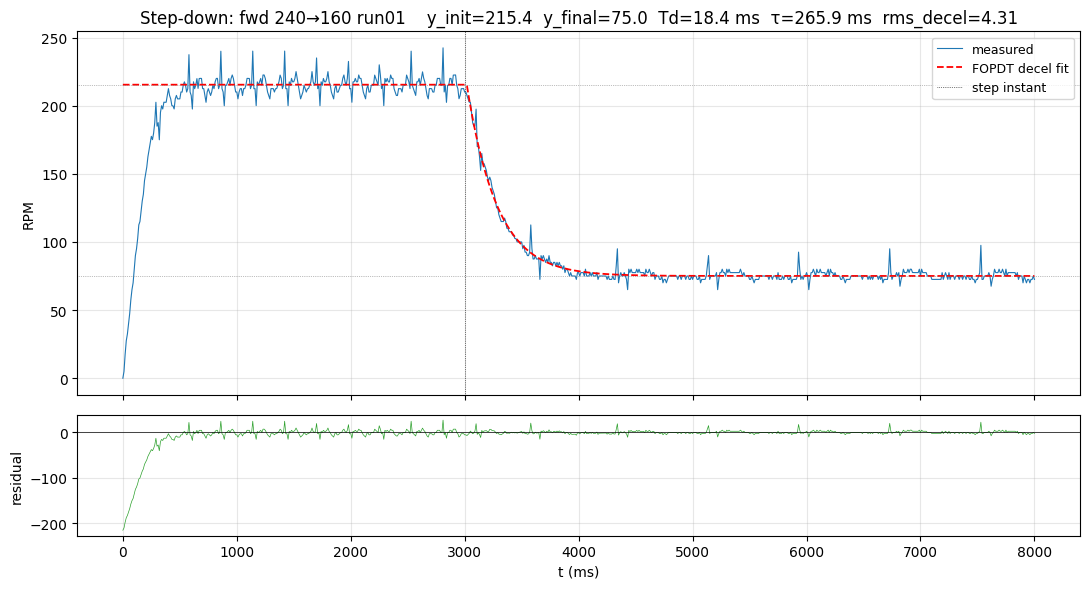

In [25]:
key = ("fwd", 240, 160, 1)
df_test = step_down_trials[key]
fit = fit_fopdt_step_down(df_test)

print(f"Trial: {key}")
print(f"  y_init  = {fit['y_init']:.1f} rpm   (expect ≈ 210, fwd 240 SS from step-ups)")
print(f"  y_final = {fit['y_final']:.1f} rpm   (expect ≈  52, fwd 160 SS from step-ups)")
print(f"  Td_ms   = {fit['Td_ms']:.1f} ms")
print(f"  tau_ms  = {fit['tau_ms']:.1f} ms     (compare: accel τ at PWM=200 ≈ 95, at PWM=240 ≈ 152)")
print(f"  rms_decel = {fit['rms_decel']:.2f} rpm")

t = df_test["t_ms"].values
r = df_test["rpm"].values
curve = fopdt_step_down_model(t, fit["y_init"], fit["y_final"], fit["Td_ms"], fit["tau_ms"])

fig, (ax_top, ax_bot) = plt.subplots(2, 1, figsize=(11, 6),
                                     gridspec_kw={"height_ratios": [3, 1]},
                                     sharex=True)
ax_top.plot(t, r, lw=0.8, color="C0", label="measured")
ax_top.plot(t, curve, "r--", lw=1.3, label="FOPDT decel fit")
ax_top.axvline(STEP_DOWN_START_MS, color="k", ls=":", lw=0.5, label="step instant")
ax_top.axhline(fit["y_init"],  color="grey", ls=":", lw=0.5)
ax_top.axhline(fit["y_final"], color="grey", ls=":", lw=0.5)
ax_top.set_ylabel("RPM")
ax_top.set_title(f"Step-down: fwd 240→160 run01    "
                 f"y_init={fit['y_init']:.1f}  y_final={fit['y_final']:.1f}  "
                 f"Td={fit['Td_ms']:.1f} ms  τ={fit['tau_ms']:.1f} ms  "
                 f"rms_decel={fit['rms_decel']:.2f}")
ax_top.legend(loc="upper right", fontsize=9)
ax_top.grid(True, alpha=0.3)

ax_bot.plot(t, r - curve, lw=0.5, color="C2")
ax_bot.axhline(0, color="k", lw=0.5)
ax_bot.set_xlabel("t (ms)")
ax_bot.set_ylabel("residual")
ax_bot.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(REPO_ROOT / "figures" / "09_stepdown_fwd_240_to_160_run01.png", dpi=140)
plt.show()

In [24]:
def fit_fopdt_step_down(df, fit_start_ms=2000):
    t_full = df["t_ms"].values.astype(float)
    r_full = df["rpm"].values.astype(float)

    fit_mask = t_full >= fit_start_ms
    t = t_full[fit_mask]
    r = r_full[fit_mask]

    init_mask  = (t >= SS_INIT_WINDOW_MS[0])  & (t <= SS_INIT_WINDOW_MS[1])
    final_mask = (t >= SS_FINAL_WINDOW_MS[0]) & (t <= SS_FINAL_WINDOW_MS[1])
    if not init_mask.any() or not final_mask.any():
        return {"fit_ok": False, "error": "ss windows empty"}

    y_init0  = r[init_mask].mean()
    y_final0 = r[final_mask].mean()
    sign = 1 if y_init0 >= 0 else -1

    if sign > 0:
        lower, upper = [0, -10, 0, 10], [400, 400, 200, 1000]
    else:
        lower, upper = [-400, -400, 0, 10], [10, 0, 200, 1000]

    try:
        popt, _ = curve_fit(
            fopdt_step_down_model, t, r,
            p0=[y_init0, y_final0, 10, 100],
            bounds=(lower, upper),
            max_nfev=5000,
        )
    except Exception as e:
        return {"fit_ok": False, "error": str(e)}

    y_init, y_final, Td, tau = popt
    res = r - fopdt_step_down_model(t, *popt)
    decel_mask = (t >= STEP_DOWN_START_MS) & (t <= STEP_DOWN_START_MS + 1500)

    return {
        "y_init": y_init, "y_final": y_final,
        "Td_ms": Td, "tau_ms": tau,
        "rms_decel": np.sqrt(np.mean(res[decel_mask]**2)),
        "rms_total": np.sqrt(np.mean(res**2)),
        "fit_ok": True,
    }

In [26]:
records = []
for (direction, start_pwm, target_pwm, run), df in step_down_trials.items():
    f = fit_fopdt_step_down(df)
    rec = {"direction": direction, "start_pwm": start_pwm,
           "target_pwm": target_pwm, "run": run}
    if f.get("fit_ok"):
        for k in ["y_init", "y_final", "Td_ms", "tau_ms", "rms_decel", "rms_total"]:
            rec[k] = f[k]
        rec["fit_ok"] = True
    else:
        for k in ["y_init", "y_final", "Td_ms", "tau_ms", "rms_decel", "rms_total"]:
            rec[k] = np.nan
        rec["fit_ok"] = False
    records.append(rec)

down_df = (pd.DataFrame(records)
             .sort_values(["direction", "start_pwm", "target_pwm", "run"])
             .reset_index(drop=True))

print(f"step-down curve_fit success: {down_df['fit_ok'].sum()} / {len(down_df)}")
print()
print(down_df.round(2).to_string(index=False))

step-down curve_fit success: 12 / 12

direction  start_pwm  target_pwm  run  y_init  y_final  Td_ms  tau_ms  rms_decel  rms_total  fit_ok
      fwd        240           0    1  214.34    -0.66  56.68  170.51       8.53       5.15    True
      fwd        240           0    2  213.94    -0.72  52.92  174.04       8.77       5.22    True
      fwd        240           0    3  214.53    -0.70  55.98  172.01       8.71       5.10    True
      fwd        240         160    1  215.39    75.02  18.35  265.92       4.31       4.21    True
      fwd        240         160    2  215.76    73.36  15.48  276.52       4.50       4.36    True
      fwd        240         160    3  215.94    72.88   8.35  283.32       4.37       4.37    True
      rev        240           0    1 -228.57    -0.00  65.36  185.47       9.65       5.11    True
      rev        240           0    2 -229.15    -0.00  58.49  193.16      10.02       5.26    True
      rev        240           0    3 -229.60    -0.00  64.95 

In [27]:
down_agg = (down_df.groupby(["direction", "start_pwm", "target_pwm"])
                   .agg(
                       y_init_mean=("y_init", "mean"),
                       y_final_mean=("y_final", "mean"),
                       Td_mean=("Td_ms", "mean"),  Td_std=("Td_ms", "std"),
                       tau_mean=("tau_ms", "mean"), tau_std=("tau_ms", "std"),
                       rms_decel_mean=("rms_decel", "mean"),
                   ).reset_index())

print("Step-down per-condition aggregates (n=3):")
print(down_agg.round(2).to_string(index=False))
print()

print("Accel τ (from curve_fit, for comparison):")
print(curve_agg[["direction", "pwm", "tau_mean", "tau_std"]].round(2).to_string(index=False))

down_df.to_csv(REPO_ROOT / "data/processed/phase21_stepdown_curvefit_per_trial.csv", index=False)
down_agg.to_csv(REPO_ROOT / "data/processed/phase21_stepdown_curvefit_per_condition.csv", index=False)
print("\nSaved.")

Step-down per-condition aggregates (n=3):
direction  start_pwm  target_pwm  y_init_mean  y_final_mean  Td_mean  Td_std  tau_mean  tau_std  rms_decel_mean
      fwd        240           0       214.27         -0.69    55.19    2.00    172.19     1.77            8.67
      fwd        240         160       215.70         73.75    14.06    5.15    275.25     8.77            4.39
      rev        240           0      -229.11         -0.00    62.93    3.85    189.54     3.87            9.78
      rev        240         160      -231.72        -85.66     9.95    0.37    306.42     3.99            2.82

Accel τ (from curve_fit, for comparison):
direction  pwm  tau_mean  tau_std
      fwd  160    200.09    22.02
      fwd  200     95.10     4.64
      fwd  240    152.26     2.74
      rev  160    191.65    12.15
      rev  200     81.24     0.94
      rev  240    144.43     2.45

Saved.


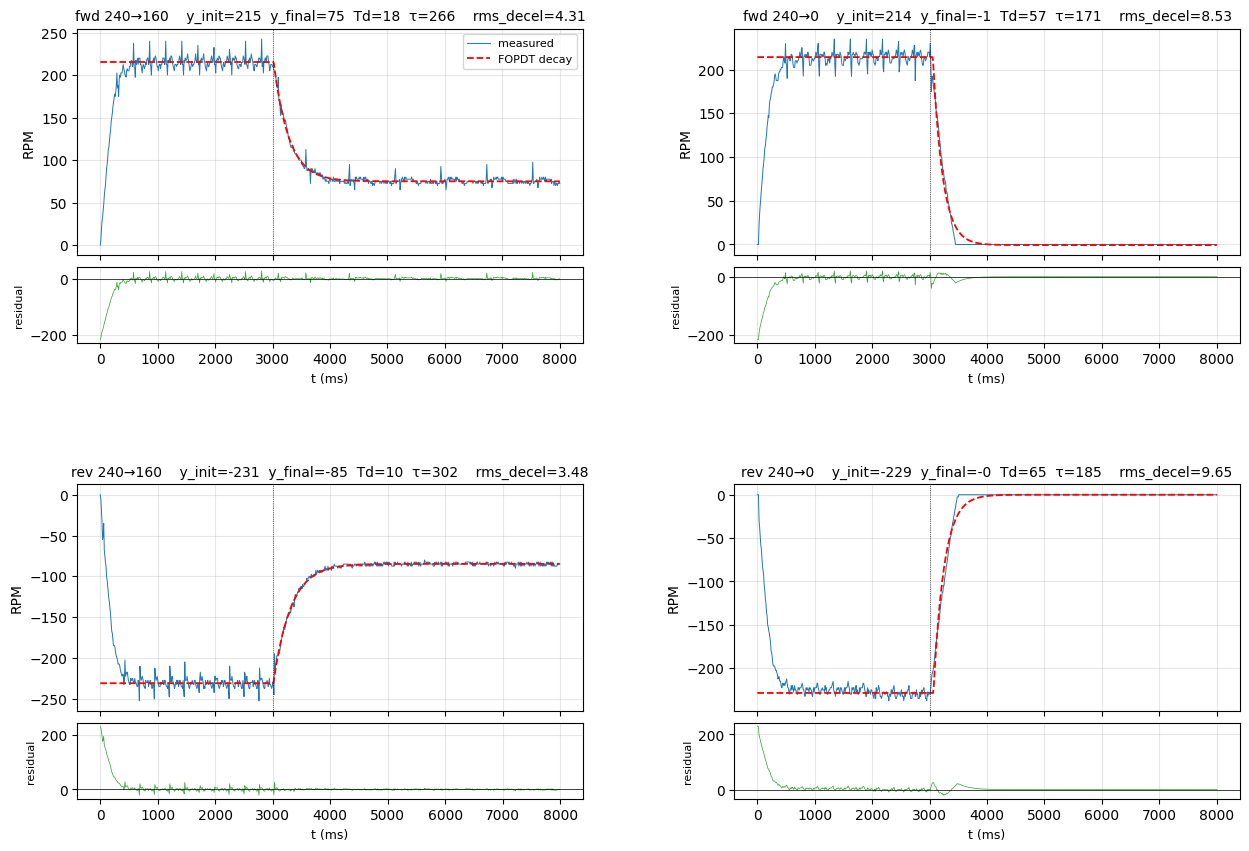

In [28]:
fig = plt.figure(figsize=(15, 10))
outer_gs = fig.add_gridspec(2, 2, hspace=0.45, wspace=0.3)

conditions = [("fwd", 240, 160), ("fwd", 240, 0),
              ("rev", 240, 160), ("rev", 240, 0)]

for idx, (direction, start_pwm, target_pwm) in enumerate(conditions):
    i, j = divmod(idx, 2)
    inner = outer_gs[i, j].subgridspec(2, 1, height_ratios=[3, 1], hspace=0.08)
    ax_top = fig.add_subplot(inner[0])
    ax_bot = fig.add_subplot(inner[1], sharex=ax_top)

    df = step_down_trials[(direction, start_pwm, target_pwm, 1)]
    f  = fit_fopdt_step_down(df)
    t  = df["t_ms"].values
    r  = df["rpm"].values

    ax_top.plot(t, r, lw=0.7, color="C0", label="measured")
    if f["fit_ok"]:
        curve = fopdt_step_down_model(t, f["y_init"], f["y_final"], f["Td_ms"], f["tau_ms"])
        ax_top.plot(t, curve, "r--", lw=1.3, label="FOPDT decay")
        ax_bot.plot(t, r - curve, lw=0.5, color="C2")
        ax_bot.axhline(0, color="k", lw=0.5)
        ax_top.set_title(
            f"{direction} {start_pwm}→{target_pwm}    "
            f"y_init={f['y_init']:.0f}  y_final={f['y_final']:.0f}  "
            f"Td={f['Td_ms']:.0f}  τ={f['tau_ms']:.0f}    "
            f"rms_decel={f['rms_decel']:.2f}",
            fontsize=10,
        )

    ax_top.axvline(STEP_DOWN_START_MS, color="k", ls=":", lw=0.5)
    ax_top.set_ylabel("RPM")
    ax_top.grid(True, alpha=0.3)
    ax_top.tick_params(labelbottom=False)
    if idx == 0:
        ax_top.legend(loc="upper right", fontsize=8)

    ax_bot.set_ylabel("residual", fontsize=8)
    ax_bot.set_xlabel("t (ms)", fontsize=9)
    ax_bot.grid(True, alpha=0.3)

plt.savefig(REPO_ROOT / "figures" / "10_stepdown_4condition_grid.png", dpi=140)
plt.show()

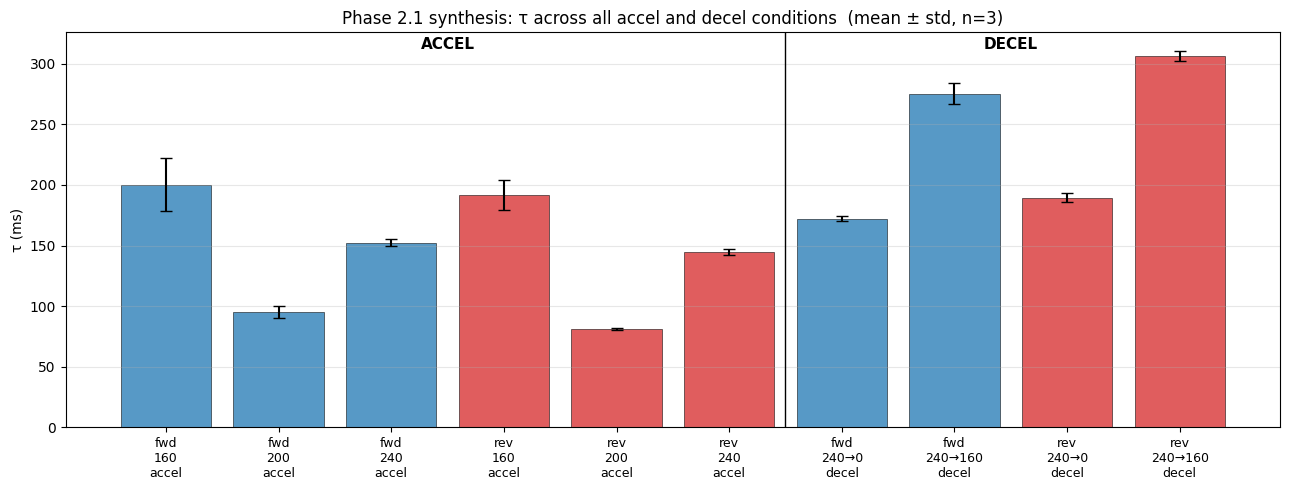

In [29]:
fig, ax = plt.subplots(figsize=(13, 5))

labels, taus, stds, colors = [], [], [], []
for _, row in curve_agg.iterrows():
    labels.append(f"{row['direction']}\n{int(row['pwm'])}\naccel")
    taus.append(row["tau_mean"]); stds.append(row["tau_std"])
    colors.append("C0" if row["direction"] == "fwd" else "C3")
for _, row in down_agg.iterrows():
    labels.append(f"{row['direction']}\n{int(row['start_pwm'])}→{int(row['target_pwm'])}\ndecel")
    taus.append(row["tau_mean"]); stds.append(row["tau_std"])
    colors.append("C0" if row["direction"] == "fwd" else "C3")

x = np.arange(len(labels))
ax.bar(x, taus, yerr=stds, capsize=4, color=colors, alpha=0.75, edgecolor="k", linewidth=0.5)
ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=9)
ax.set_ylabel("τ (ms)")
ax.set_title("Phase 2.1 synthesis: τ across all accel and decel conditions  (mean ± std, n=3)")
ax.grid(True, alpha=0.3, axis="y")
ax.axvline(5.5, color="k", lw=1)
ax.text(2.5, max(taus)*1.02, "ACCEL",  ha="center", fontsize=11, fontweight="bold")
ax.text(7.5, max(taus)*1.02, "DECEL",  ha="center", fontsize=11, fontweight="bold")

plt.tight_layout()
plt.savefig(REPO_ROOT / "figures" / "11_phase21_tau_synthesis.png", dpi=140)
plt.show()